# Hackathon - Metodos de Analisis de Datos 1

***Alumno:*** Martin Godoy


***Universidad Nacional del Sur***

---

## Importe de librerias

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente')

Librerías importadas correctamente


### Creamos el dataset

Crearemos un dataset con los datos de el archivo csv de ordenes de compras municipales.

In [35]:
#Leemos el archivo OCM24 (Ordenes de compra municipales 2024)
df = pd.read_csv('OCM24.csv') 

#Observamos las 10 primeras filas
df.head(10)

,ejercicio,ordencompra,fecha,importe,proveedor,dependencia,expediente
0,2024,7486,21-10-2024,3.477154e+04,PROMAR S.R. L,DIRECCION GENERAL DE EDUCACION,Suministro 7507/2024
1,2024,7497,22-10-2024,2.815000e+08,SOLUCIONES TURISTICAS SRL.,INSTITUTO DEL DEPORTE,Suministro 5536/2024
2,2024,307,30-01-2024,7.435440e+05,NAVARRETE YAMILA MALENA,SEC. DE OBRAS Y SERVICIOS PUBLICOS,Suministro 393/2024
3,2024,1739,25-03-2024,2.050000e+05,ACQUAMANSA,TEATRO MUNICIPAL,Suministro 2210/2024
4,2024,2991,15-05-2024,1.933479e+05,CODIMAT S.A.,DIRECCION GENERAL DE DISCAPACIDAD Y ACCESIBILIDAD,Suministro 3344/2024
5,2024,434,07-02-2024,1.250000e+06,CACU CLIMATIZACION,SEC. DE SALUD,Suministro 402/2024
6,2024,7013,30-09-2024,1.050000e+06,COPYFAX FOTOCOPIADORAS S.R.L.,TRIBUNAL DE FALTAS,Suministro 7082/2024
7,2024,7617,25-10-2024,1.635000e+05,GRUPO BAHIA BLANCA,DEPARTAMENTO TALLERES Y MAESTRANZA,Suministro 7645/2024
8,2024,7659,29-10-2024,1.155000e+06,MEDICA BAHIA,SEC. DE SALUD,Suministro 7665/2024
9,2024,896,29-02-2024,5.857750e+05,GAVILAN MONICA PATRICIA,MAMAS CUIDADORAS,Suministro 1026/2024


In [36]:
#Obtenemos información del dataset
print("Informacion del dataset:")
df.info()

Informacion del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 8559 entries, 0 to 8558
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ejercicio    8559 non-null   int64  
 1   ordencompra  8559 non-null   int64  
 2   fecha        8559 non-null   str    
 3   importe      8559 non-null   float64
 4   proveedor    8559 non-null   str    
 5   dependencia  8559 non-null   str    
 6   expediente   8559 non-null   str    
dtypes: float64(1), int64(2), str(4)
memory usage: 468.2 KB


In [37]:
#Obtenemos información general del datasheet
print(f"Informacion general del datasheet:")
df.describe()

Informacion general del datasheet:


,ejercicio,ordencompra,importe
count,8559.0,8559.000000,8.559000e+03
mean,2024.0,4444.825797,7.366996e+06
std,0.0,2568.933889,1.102961e+08
min,2024.0,1.000000,4.200000e+02
25%,2024.0,2227.500000,2.190050e+05
50%,2024.0,4434.000000,6.561041e+05
75%,2024.0,6646.500000,1.696600e+06
max,2024.0,9581.000000,5.786833e+09


Tenemos información sobre la media, min, max y desvió estándar.

---

## Pasamos a verificar la calidad de los datos

### Valores faltantes

In [38]:
#Detectamos los valores que falten
print("Valores faltantes por columna:")
df.isnull().sum()

Valores faltantes por columna:


ejercicio      0
ordencompra    0
fecha          0
importe        0
proveedor      0
dependencia    0
expediente     0
dtype: int64

In [39]:
#Estandarizamos los nombres en las columnas 'dependencia' y 'proveedor' para evitar problemas de análisis posteriores
df['proveedor'] = df['proveedor'].str.strip().str.upper()
df['dependencia'] = df['dependencia'].str.strip().str.upper()

### Valores duplicados

In [40]:
#Eliminamos los duplicados
print(f"Dataset antes de eliminar duplicados: {df.shape[0]} filas")
df = df.drop_duplicates()
print(f"Dataset después de eliminar duplicados: {df.shape[0]} filas") 

Dataset antes de eliminar duplicados: 8559 filas
Dataset después de eliminar duplicados: 8559 filas


### Inconsistencias en los valores

In [41]:
#Detección de valores anormales:

#Orden de compra negativo
ordencompra_negativo = df[df['ordencompra'] < 0]

#Ejercicio de otro año
ejercicio_diferente = df[df['ejercicio'] !=2024]

#importe fuera de rango
importe_fuera_rango = df[(df['importe'] < 0)]

print("Ordenes de compra negativas:", len(ordencompra_negativo))
print("Ejercicios diferentes a 2024:", len(ejercicio_diferente))
print("Importes fuera de rango:", len(importe_fuera_rango))


Ordenes de compra negativas: 0
Ejercicios diferentes a 2024: 0
Importes fuera de rango: 0


Se verificaron posibles inconsistencias con los datos, sin embargo, el dataset no posee datos fuera de rango e inconsistentes por tanto, no hay necesidad de una corrección. 

Nota: Se decidió no acotar al importe ni superior ni interiormente, puesto que, revisando la procedencia de importes tan altos (de $5.786833e+09 por ejemplo) o importes tan bajos ($420.00), tienen sentido dentro de su contexto, y son datos que valen la pena tener en cuenta para el análisis. 

In [42]:
df_ordenadodecr = df.sort_values(by='importe', ascending=False)
print(f"Dataset ordenado de forma decreciente:\n{df_ordenadodecr.head()}")
df_ordenadocrec = df.sort_values(by='importe', ascending=True)
print(f"Dataset ordenado de forma creciente:\n{df_ordenadocrec.head()}")

Dataset ordenado de forma decreciente:
      ejercicio  ordencompra       fecha       importe  \
6766       2024         7050  30-09-2024  5.786833e+09   
2970       2024         4391  28-06-2024  5.283638e+09   
3167       2024         1864  27-03-2024  4.651707e+09   
2534       2024         7767  31-10-2024  2.536785e+09   
394        2024         5573  21-08-2024  2.000000e+09   

                          proveedor                            dependencia  \
6766          BAHIA AMBIENTAL SAPEM              SUBSECRETARIA DE AMBIENTE   
2970          BAHIA AMBIENTAL SAPEM              SUBSECRETARIA DE AMBIENTE   
3167          BAHIA AMBIENTAL SAPEM              SUBSECRETARIA DE AMBIENTE   
2534                   DANAIDE S.A.  SUBSECRETARIA DE PROTECCION CIUDADANA   
394   INGENIERIA Y ARQUITECTURA SRL              SUBSECRETARIA DE AMBIENTE   

                expediente  
6766  Suministro 7320/2024  
2970  Suministro 4834/2024  
3167  Suministro 2369/2024  
2534  Suministro 7802/2024 

---

## Frecuencia por dependencias, por proveedores y evolución temporal a lo largo del año

In [43]:
#Conteo de distribución de valores en la columna de 'dependencia'
df['dependencia'].value_counts().head(30)

dependencia
DEPARTAMENTO TALLERES Y MAESTRANZA                   733
INSTITUTO CULTURAL MUNICIPAL                         667
SEC. DE SALUD                                        604
INTENDENCIA                                          563
H.C.D.                                               278
INSTITUTO DEL DEPORTE                                249
SUBSECR. DE NINEZ, ADOLESC. Y FAMILIA                239
DIV. DE CONTROL Y ORDENAMIENTO URBANO                217
DIRECCION GENERAL DE EDUCACION                       202
DEP. PROYECTOS Y OBRAS                               193
SUBSECRETARIA DE AMBIENTE                            151
DEP. MANTENIMIENTO DE ALUMBRADO PUBLICO              144
SEC. DE OBRAS Y SERVICIOS PUBLICOS                   143
SUBSECRETARIA DE PROTECCION CIUDADANA                135
DIVISION DESARROLLO SOCIAL                           129
SUBSECRETARIA RELACIONES INSTITUCIONALES Y CULTO     117
DEP. ELECTRICIDAD Y MECANICA                         107
SUBSECRETARIA DE HA

Text(0, 0.5, 'Cantidad')

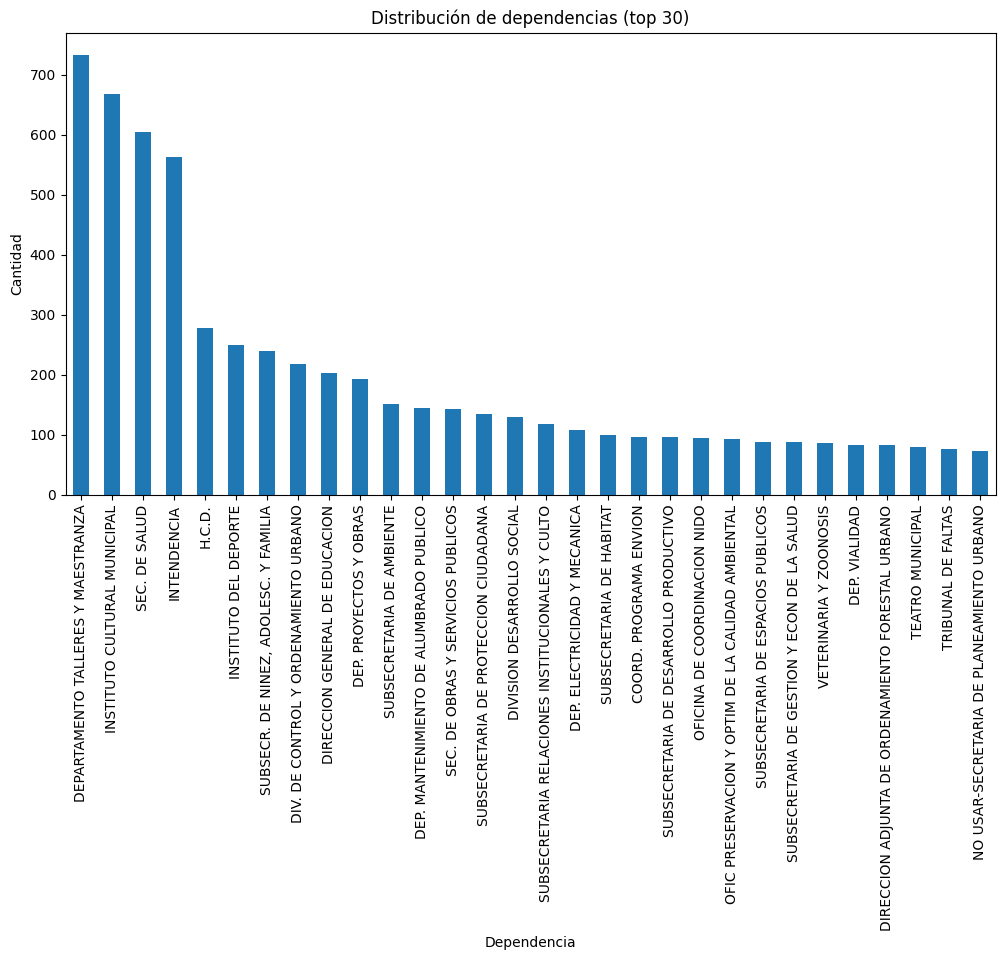

In [44]:
#Gráficamente, vemos la distribución en la columna de 'dependencia'
df['dependencia'].value_counts().head(30).plot(kind='bar', figsize=(12,6))
plt.title('Distribución de dependencias (top 30)')
plt.xlabel('Dependencia')
plt.ylabel('Cantidad')

In [45]:
#Conteo de distribución de valores en la columna de 'proveedor'
df['proveedor'].value_counts().head(30)

proveedor
LA MOLIENDA                                                      193
CODIMAT S.A.                                                     172
AÑOS LUZ                                                         155
ECOBAHIA S.A.                                                    102
FERRETERIA CENTRO                                                 93
ACQUAMANSA                                                        83
PROMAR S.R. L                                                     76
REPUESTOS TATO                                                    69
REPUESTOS LASPIUR                                                 58
ALVAREZ NEUMATICOS S.A.                                           57
DISPROAL                                                          56
CACU CLIMATIZACION                                                51
AQUALIFE                                                          49
LA CASA DEL CARTUCHO - LUIS J. DREVNIAK MATERIALES ELECTRICOS     47
HIPERTEHUELCHE          

Text(0, 0.5, 'Cantidad')

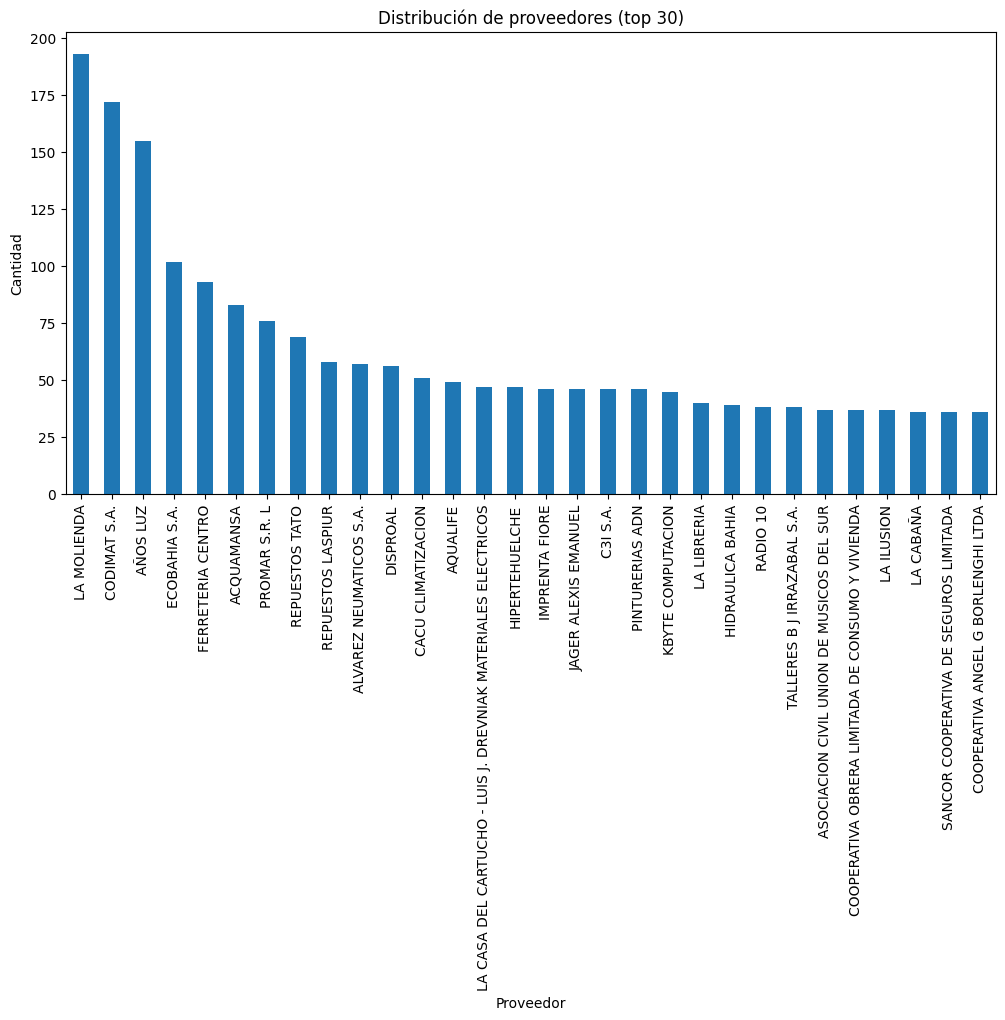

In [46]:
#Gráficamente vemos la distribución en la columna de 'proveedor'
df['proveedor'].value_counts().head(30).plot(kind='bar', figsize=(12,6))
plt.title('Distribución de proveedores (top 30)')
plt.xlabel('Proveedor')
plt.ylabel('Cantidad')

---

## Transformación de datos

In [47]:
#Verificamos los tipos de datos actuales
print("Tipos de datos actuales:")
print(df.dtypes)

Tipos de datos actuales:
ejercicio        int64
ordencompra      int64
fecha              str
importe        float64
proveedor          str
dependencia        str
expediente         str
dtype: object


In [ ]:
#Elegimos las 20 dependencias con mayor frecuencia y separamos el resto en la categoría 'OTROS' 
top_dependencias = list(df['dependencia'].value_counts().head(20).index)

df.loc[~df['dependencia'].isin(top_dependencias), 'dependencia'] = 'OTROS'
print(df['dependencia'].value_counts().head(20))

#Elegimos los 10 proveedores con mayor importe total y 10 de los proveedores con mayor frecuencia, separamos al resto en la categoría 'OTROS'
top_freq = list(df['proveedor'].value_counts().head(10).index)
top_impact = list(df.groupby('proveedor')['importe'].sum().sort_values(ascending=False).head(10).index)

top_proveedores = top_freq + top_impact
top_proveedores = list(set(top_proveedores))  # Eliminamos duplicados

df.loc[~df['proveedor'].isin(top_proveedores), 'proveedor'] = 'OTROS'
print("\n",df['proveedor'].value_counts().head(20))

dependencia
OTROS                                               3396
DEPARTAMENTO TALLERES Y MAESTRANZA                   733
INSTITUTO CULTURAL MUNICIPAL                         667
SEC. DE SALUD                                        604
INTENDENCIA                                          563
H.C.D.                                               278
INSTITUTO DEL DEPORTE                                249
SUBSECR. DE NINEZ, ADOLESC. Y FAMILIA                239
DIV. DE CONTROL Y ORDENAMIENTO URBANO                217
DIRECCION GENERAL DE EDUCACION                       202
DEP. PROYECTOS Y OBRAS                               193
SUBSECRETARIA DE AMBIENTE                            151
DEP. MANTENIMIENTO DE ALUMBRADO PUBLICO              144
SEC. DE OBRAS Y SERVICIOS PUBLICOS                   143
SUBSECRETARIA DE PROTECCION CIUDADANA                135
DIVISION DESARROLLO SOCIAL                           129
SUBSECRETARIA RELACIONES INSTITUCIONALES Y CULTO     117
DEP. ELECTRICIDAD Y

Debido a la alta cantidad de valores únicos que están presentes tanto en 'dependencia' como en 'proveedor' y, con la finalidad de mejorar la estabilidad del modelado, decidimos acotar un poco las categorías eligiendo (de manera arbitraria) 20 de ellas (manteniendo las que son consideradas mas representativas) y agrupándolas como sigue:

Dependencia: Elegimos las dependencias con mayor frecuencia ya que representan las áreas con mayor actividad dentro del municipio y permiten capturar la mayor parte del funcionamiento municipal en gasto. A diferencia de los proveedores donde la frecuencia y el impacto económico no suelen ir de la mano, las dependencias presentan una estructura mas estable y representativa mediante su frecuencia de aparición.

Proveedor: Elegimos los 10 proveedores con mayor importe total y 10 de los proveedores que aparecen con mayor frecuencia, esto ultimo con el fin de preservar información relevante desde dos puntos distintos: La frecuencia de aparición de proveedores que están asociados con compras recurrentes y el peso económico vinculado a contratos mucho mas grandes.

In [ ]:
#Convertimos tipos
df['fecha'] = pd.to_datetime(df['fecha'], format='%d-%m-%Y')
df['ejercicio'] = df['ejercicio'].astype(str)
df['ordencompra'] = df['ordencompra'].astype(str)

#Convertimos a categorías las columnas de 'dependencia' y 'proveedor' eligiendo 20 dependencias y 20 proveedores (como fue detallado arriba) y agrupando el resto en 'OTROS'
df['dependencia'] =pd.Categorical(
    df['dependencia'],
    categories = top_dependencias + ['OTROS'],
    ordered = False
)
df['proveedor'] =pd.Categorical(
    df['proveedor'],
    categories = top_proveedores + ['OTROS'],
    ordered = False
)

#Extraemos variables nuevas a partir de la fecha (mes y dia de la semana)
df['mes'] = df['fecha'].dt.month
df['dia_semana'] = df['fecha'].dt.day_of_week

Se cambio de tipo de: 
- Fecha: Se cambio su tipo de str a datetime con el fin de trabajarlo a posteriori de una mejor forma, extrajimos de paso variables nuevas a partir de la misma que podrían tener un juego interesante, en nuestro caso fueron mes y dia de la semana.
- Ejercicio: Se cambio su tipo de int a str para trabajarlo con mayor comodidad, como un id por ejemplo, mas que como un numero en si.
- Orden de compra: Como con el ejercicio, se cambio de int a str y lo que motivo este cambio fue lo mismo que motivo el cambio de ejercicio, es decir, para un trabajo mas cómodo y considerándolo como una id mas que como un numero.
- Dependencia y proveedor: Cambiamos el tipo de dato de dependencia y proveedor de str a categórico, esto debido a que, resulta util ver cual es el importe total que tienen ambas variables en un conjunto especifico escogido (como esta explicado antes) y una forma cómoda de hacer esta observación es separando por categorías.

---

## Evolución temporal a lo largo del año

Text(0, 0.5, 'Importe total')

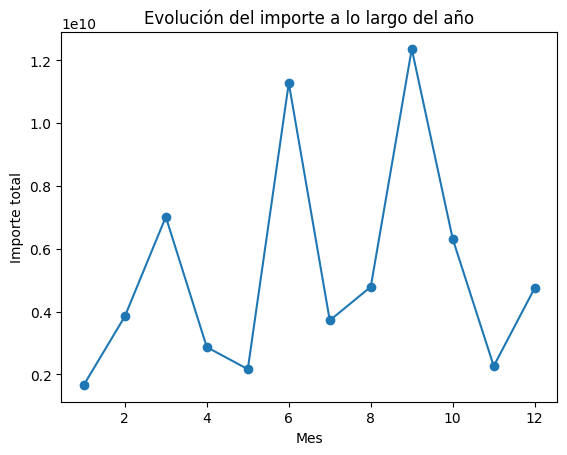

In [50]:
#Vemos como fue la evolución del importe a lo largo del año
df.groupby('mes')['importe'].sum().plot(kind='line', marker='o')
plt.title('Evolución del importe a lo largo del año')
plt.xlabel('Mes')
plt.ylabel('Importe total')

---

## Modelado

En este caso vamos a usar un modelado por Regresión Lineal utilizando la librería de statsmodels.

In [51]:
#Importamos las librerías necesarias para el modelado
import statsmodels.api as sm
from statsmodels.formula.api import ols 
from sklearn.model_selection import train_test_split  

#Cargamos datos para el modelado
data = df.copy()

#Dividimos el dataset en conjunto de entrenamiento y prueba (80% entrenamiento, 20% prueba)
train, test = train_test_split(data, test_size=0.2, random_state=42)

#Ajustamos el modelo de regresión lineal con las variables categóricas de 'dependencia', 'proveedor' y consideramos también el mes y el día de la semana como variables numéricas
modelo = ols('np.log1p(importe) ~ C(dependencia) + C(proveedor) + C(mes) + C(dia_semana)', data=train).fit()

#Resumen completo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:      np.log1p(importe)   R-squared:                       0.202
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     31.31
Date:                Wed, 06 May 2026   Prob (F-statistic):               0.00
Time:                        15:45:10   Log-Likelihood:                -12527.
No. Observations:                6847   AIC:                         2.517e+04
Df Residuals:                    6791   BIC:                         2.555e+04
Df Model:                          55                                         
Covariance Type:            nonrobust                                         
                                                                         coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

Se utilizo un modelo de regresión lineal debido a la simplicidad e interpretabilidad que este aporta, permitiéndonos analizar el efecto de distintas variables sobre los importes de compra. Cabe aclarar que el modelado se realizo sobre el logaritmo de el importe, pues la variable objetivo posee una distribución sesgada, el usar esta transformación nos permite relajar un poco la distancia numérica que hay entre los valores mas bajos de la variable importe y los mas altos (pues esta distancia originalmente es muy grande).

Se incluyeron variables relacionadas con la dependencia y el proveedor para capturar diferencias en los gastos de cada uno, también, se incluyeron variables temporales (mes y dia de la semana) con el fin de modelar algún posible patrón estacional.

Dado a que se opto por un modelo de regresión lineal, no se requirieron selecciones de hiperparámetros complejos. Sin embargo, se tomaron ciertas decisiones de modelado relevantes como la transformación logarítmica de la variable objetivo y el tratamiento de variables categóricas.

Para evaluar el desempeño del modelado, se dividió el dataset en una distribución 80/20 con el fin de hacer una sección de entrenamiento-prueba (train-test) para conseguir un mejor resultado con el modelado.

---

## Algunos gráficos

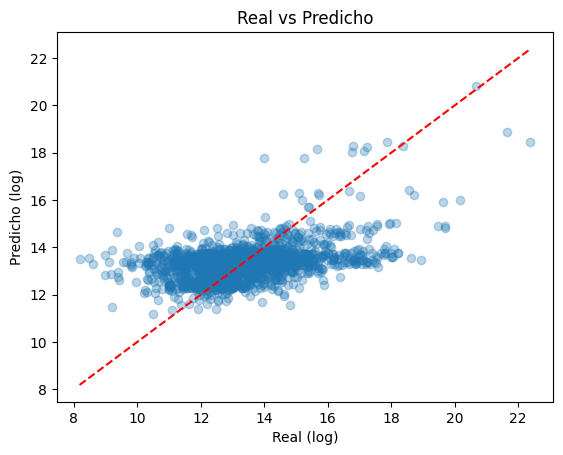

In [52]:
#Visualizamos el gráfico de valores predichos vs valores reales para evaluar el ajuste del modelo
y_test = np.log1p(test["importe"])
y_pred = modelo.predict(test)

plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Real (log)")
plt.ylabel("Predicho (log)")
plt.title("Real vs Predicho")
plt.show()


El gráfico de valores reales vs predichos muestra una relación positiva entre ambas variables lo que puede indicar que el modelo logra capturar parcialmente las tendencias generales del importe. Sin embargo, se observa una dispersión considerable respecto a la linea de predicción perfecta, lo que evidencia, ciertas limitaciones en la precisión del modelo.

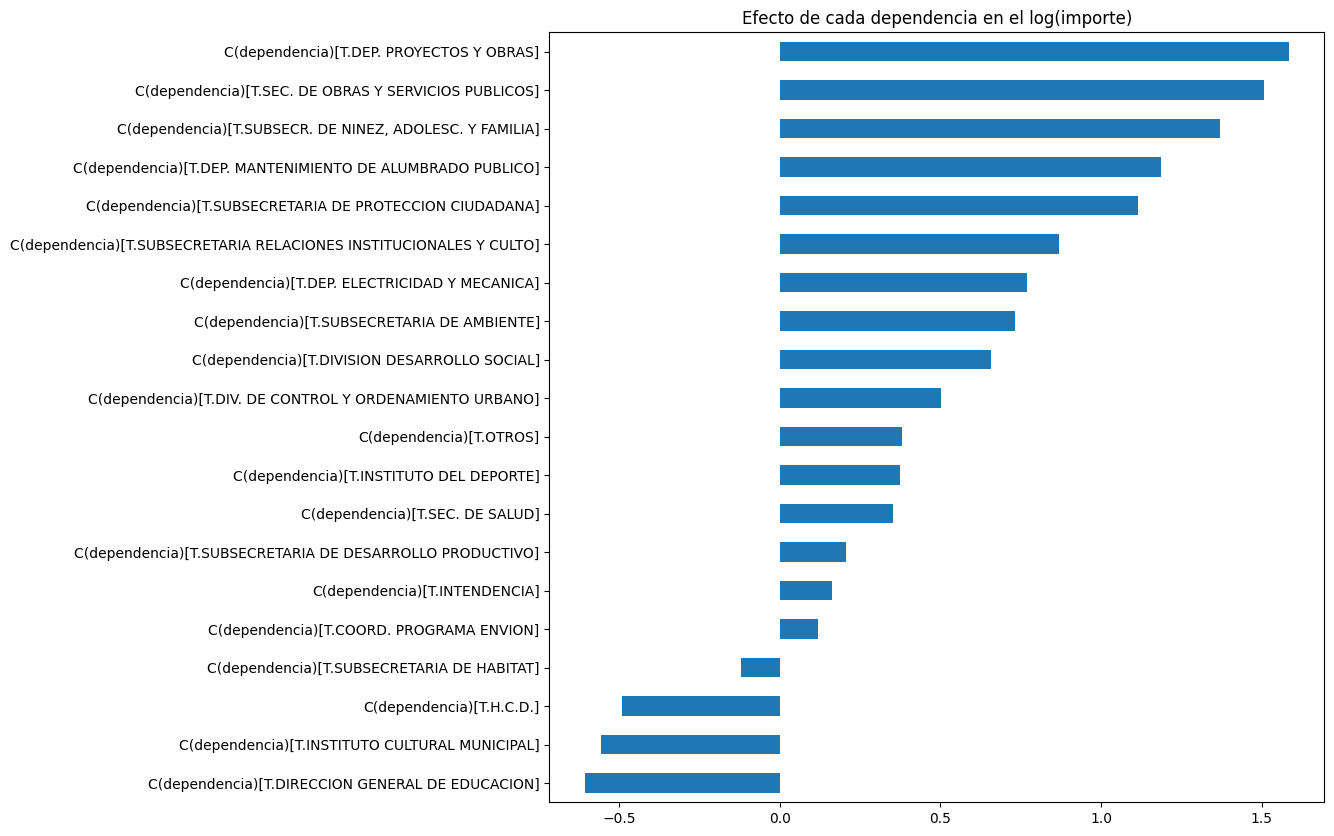

In [53]:
#Efecto de la variable dependencia en el log(importe)
coef_dep = modelo.params.filter(like="dependencia")

coef_dep.sort_values().plot(kind="barh", figsize=(10,10))
plt.title("Efecto de cada dependencia en el log(importe)")
plt.show()

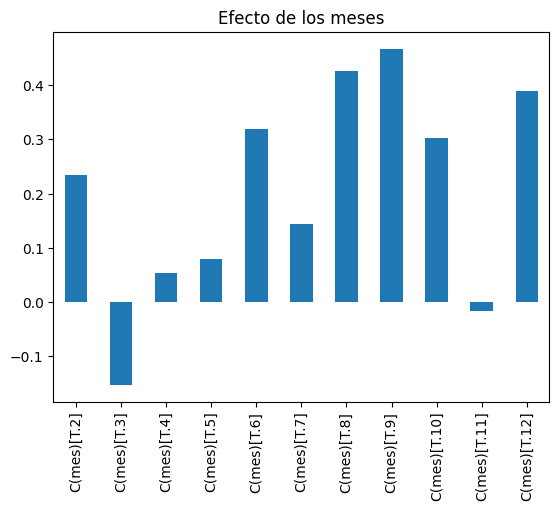

In [54]:
#Efecto de la variable meses sobre log(importe)
coef_mes = modelo.params.filter(like="mes")

coef_mes.plot(kind="bar")
plt.title("Efecto de los meses")
plt.show()

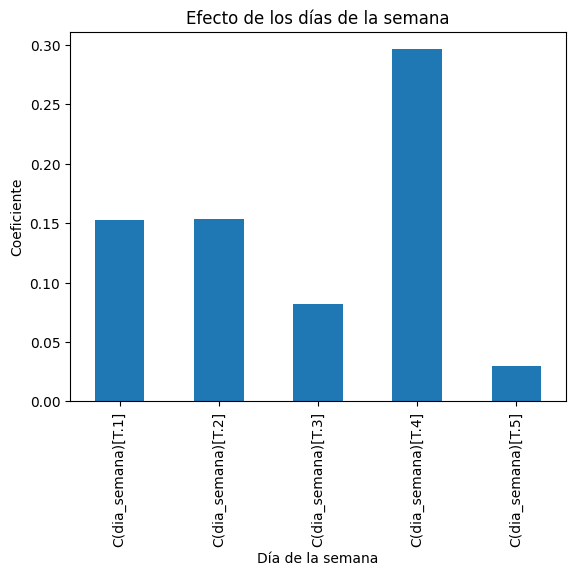

In [55]:
#Efecto de la variable dia_semana sobre log(importe)
coef_dia = modelo.params.filter(like="dia_semana")

coef_dia.plot(kind="bar")
plt.title("Efecto de los días de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Coeficiente")
plt.show()

--- 

## Diagnostico

In [56]:
#Calculamos el RMSE para evaluar el rendimiento del modelo
from sklearn.metrics import mean_squared_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("La raíz del error cuadrático medio resulta (RMSE):", rmse)

La raíz del error cuadrático medio resulta (RMSE): 1.5242384856091464


La media de los residuos (test) es: 0.04414036972398064


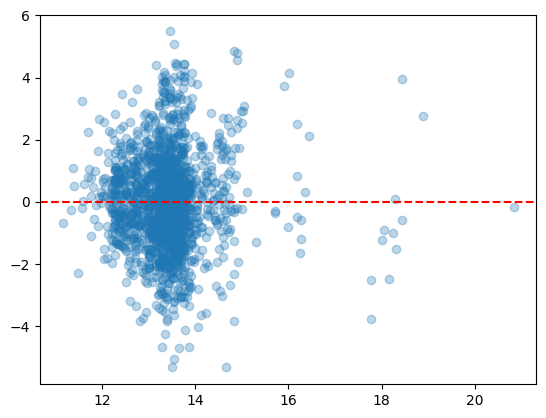

In [57]:
#Analizamos los residuos del modelo en test
residuos_test = y_test - y_pred

print("La media de los residuos (test) es:", residuos_test.mean())

plt.scatter(y_pred, residuos_test, alpha=0.3)
plt.axhline(0, color='r', linestyle='--')
plt.show()

Text(0.5, 1.0, 'Distribución de los residuos (test)')

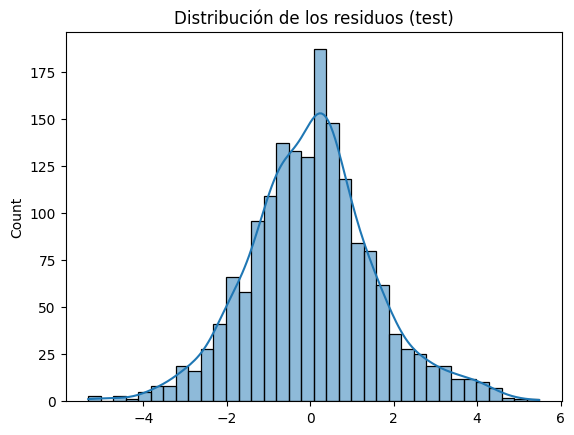

In [58]:
#Visualizamos la distribución de los residuos test
sns.histplot(residuos_test, kde=True)
plt.title("Distribución de los residuos (test)")

Al momento de hacer la división para train-test (o entrenamiento-validación) se opto por una distribución del 80/20 de los datos (80% al entrenamiento 20% a la validación) en un ejercicio de maximizar la Informacion disponible para la fase de entrenamiento y, a su vez, dejar una buena cantidad de datos sin observar para la fase de validación, de esta forma, consiguiéndose un balance adecuado.

En nuestro caso, el modelo presento los siguientes datos:
- R^2 ajustado: El modelo presento un R^2 ajustado de 0,196 , siendo este un valor bastante bajo para el mismo, esto indica que el modelo es capaz de explicar una proporción bastante limitada (mas no nula) de la variabilidad del importe.
- RMSE: El RMSE obtenido de 1.52 (en escala logarítmica que se corresponde con un 4.57 en escala normal) sugiere un nivel de error considerable en las predicciones esto, aun asi, resulta algo esperable dado el amplio rango de valores de importe.
- Residuos: El análisis de residuos no evidencia ningún patrón lineal claro, asimismo, la media se mantiene bastante cercana a 0 indicando ausencia de sesgos importantes, sin embargo, se observan algunos valores atípicos y una ligera heterocedastisidad, que es consistente con la variabilidad de los datos en si.


Poniéndolo todo junto el modelo podría resultar util para identificar tendencias generales, aunque, presenta ciertas limitaciones en su capacidad predictiva


---
---

## Interpretación 

Los criterios que tenemos para valorar las variables y su importancia dependerá de su coeficiente y su significancia, consideraremos concretamente aquellas variables que posean:
- abs(coef) > 0.3 que al considerar importes en  escala logarítmica, se corresponde (aproximadamente) con un porcentaje mayor (o menor respectivamente) que ∓ 30% de importe respecto a algún valor único elegido por el modelado (en caso de variables numéricas como mes y dia_semana sera respecto a enero/lunes respectivamente)
- Significancia con p-valor < 0.05

Teniendo en cuenta esto el análisis de los coeficientes del modelo indica que las variables con mayor influencia en el importe son los proveedores y las dependencias, lo que sugiere que el gasto municipal esta fuertemente determinado por el area que realiza la compra y el proveedor que se ve involucrado en la misma. Algunas variables temporales como el mes y el dia de la semana, presentan coeficientes estadísticamente significativos, lo que podría indicar que existen ciertos patrones relacionados con fenómenos temporales, sin embargo, la magnitud de estos efectos es relativamente menor en comparación con la magnitud de los mencionados anteriormente (dependencia y proveedor).

Es interesante recalcar que existen ciertas dependencias con coeficientes significativamente mayores, eso nos quiere decir que existe una mayor concentración de gasto en áreas especificas del municipio como por ejemplo: 
- SEC. DE OBRAS Y SERVICIOS PUBLICOS con un 1.505 de coeficiente, lo que equivale aproximadamente a un +150% en comparación con la  dependencia de referencia.
- SUBSECR. DE NINEZ, ADOLESC. Y FAMILIA con un 1.370 de coeficiente, equivalente aproximadamente a un +137% en comparación con la dependencia de referencia .

Que pensándolo fríamente es un dato que no resulta descabellado, pues son áreas grandes del municipio y eso traerá consigo unos mayores gastos 

Por su parte, también, la variable proveedor muestra un impacto bastante relevante, cosa que podría indicar la existencia de contratos o relaciones comerciales de mayor magnitud con proveedores en especifico

---

## Concluyendo

Todo lo visto puede sugerir que el gasto municipal efectuado por Bahía Blanca en el año 2024, parece estar mucho mas determinado por factores estructurales (dependencia y proveedor) que no por otros factores temporales (mes y dia de la semana).

El modelo probabilístico no resulto ser el mejor dentro de su capacidad explicativa y a pesar de que podría resultar util para identificar patrones generales en los datos, con la exploración de un modelo mas complejo y un mejor manejo de los datos en general, considero que podrían conseguirse unos resultados mas 'jugosos' y, probablemente, conseguir una mejor capacidad explicativa.

En conjunto, el modelo permite comprender las dinámicas principales del gasto municipal en 2024 aunque presenta ciertas carencias al ser un fenómeno complejo de estudiar y evidencia la posible necesidad de un enfoque mas amplio para su predicción precisa

---